# 2024-05-25-Preprocessing: Generating scGPT embeddings using the pretrained scGPT model

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import mode
import scanpy as sc
import sklearn
import warnings

import scgpt as scg

/lustre/home/fluebeck/micromamba/envs/vcells/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/lustre/home/fluebeck/micromamba/envs/vcells/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


In [2]:
data_cache_dir = './perturbench_data' ## Change this to your local data directory

In [3]:
# whole-human pretrained model is downloaded from:
# https://github.com/bowang-lab/scGPT?tab=readme-ov-file#pretrained-scgpt-model-zoo

model_dir = Path(f"{data_cache_dir}/pretrained_models/scGPT_human")


In [4]:
import os
os.listdir("perturbench_data/pretrained_models/scGPT_human")

['best_model.pt', 'args.json', 'vocab.json']

### norman19

In [6]:
datapath = f'{data_cache_dir}/norman19_processed.h5ad'

In [7]:
adata = sc.read_h5ad(datapath)

In [8]:
adata_copy = adata.copy()

In [9]:
adata_copy.X = adata_copy.layers['counts']

In [10]:
adata.var.head()

,ensemble_id,ncounts,ncells,n_cells,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
RP11-501C14.5,ENSG00000250838,9249.0,8745,8745,8745,0.082992,0.079727,92.153080,9249.0,9.132379,False,NaN,0.082992,0.085706,0.976498,0
CAPN1,ENSG00000014216,62520.0,45396,45396,45396,0.560994,0.445323,59.266006,62520.0,11.043258,True,2832.0,0.560994,0.680276,1.019107,1
FAXC,ENSG00000146267,4630.0,4486,4486,4486,0.041545,0.040705,95.974696,4630.0,8.440528,False,NaN,0.041545,0.042565,0.968249,0
OBSCN,ENSG00000154358,8001.0,7546,7546,7546,0.071793,0.069333,93.228947,8001.0,8.987447,False,NaN,0.071793,0.075451,0.994966,0
EBLN3,ENSG00000281649,18300.0,16391,16391,16391,0.164207,0.152040,85.292297,18300.0,9.814711,True,3827.0,0.164207,0.175793,0.998370,1


In [58]:
adata_copy_embeddings = scg.tasks.embed_data(
    adata_copy,
    model_dir,
    gene_col="index",#,'gene_symbol',
    batch_size=128,
    return_new_adata=True,
)

scGPT - INFO - match 5235/5666 genes in vocabulary of size 60697.


/lustre/home/fluebeck/micromamba/envs/vcells/lib/python3.10/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 871/871 [02:28<00:00,  5.86it/s]
/lustre/home/fluebeck/micromamba/envs/vcells/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [59]:
adata_copy_embeddings.X.shape

(111445, 512)

In [60]:
adata.obsm['scgpt_embbeddings'] = adata_copy_embeddings.X

In [61]:
adata

AnnData object with n_obs × n_vars = 111445 × 5666
    obs: 'guide_id', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'tissue_type', 'cell_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'condition', 'cov_merged', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'ensemble_id', 'ncounts', 'ncells', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'rank_genes_groups_cov'
    obsm: 'scgpt_embbeddings'
    layers: 'counts'

In [62]:
outfile = f'{data_cache_dir}/norman19_preprocessed_with_embeddings.h5ad'

In [63]:
adata.write_h5ad(outfile)

### mcfaline23

In [18]:
datapath = f'{data_cache_dir}/frangieh21_processed.h5ad'

In [19]:
adata = sc.read_h5ad(datapath)

In [20]:
adata

AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'umap_x', 'umap_y', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'cell_type', 'treatment', 'condition', 'dataset'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [21]:
adata_copy = adata.copy()

In [7]:
adata_copy.X = adata_copy.layers['counts']

In [23]:
adata_copy_embeddings = scg.tasks.embed_data(
    adata_copy,
    model_dir,
    gene_col="index",
    batch_size=128,
    return_new_adata=True,
)

scGPT - INFO - match 18373/23712 genes in vocabulary of size 60697.


/lustre/home/fluebeck/micromamba/envs/vcells/lib/python3.10/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1706/1706 [04:47<00:00,  5.94it/s]
/lustre/home/fluebeck/micromamba/envs/vcells/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [24]:
adata.obsm['scgpt_embbeddings'] = adata_copy_embeddings.X

In [25]:
adata

AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'umap_x', 'umap_y', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'cell_type', 'treatment', 'condition', 'dataset'
    var: 'ensembl_id', 'ncounts', 'ncells'
    obsm: 'scgpt_embbeddings'

In [26]:
outfile = f'{data_cache_dir}/frangieh21_processed_with_embeddings.h5ad'

In [27]:
adata.write_h5ad(outfile)

In [31]:
adata

AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'umap_x', 'umap_y', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'cell_type', 'treatment', 'condition', 'dataset'
    var: 'ensembl_id', 'ncounts', 'ncells'
    obsm: 'scgpt_embbeddings'

/lustre/home/fluebeck/micromamba/envs/vcells/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


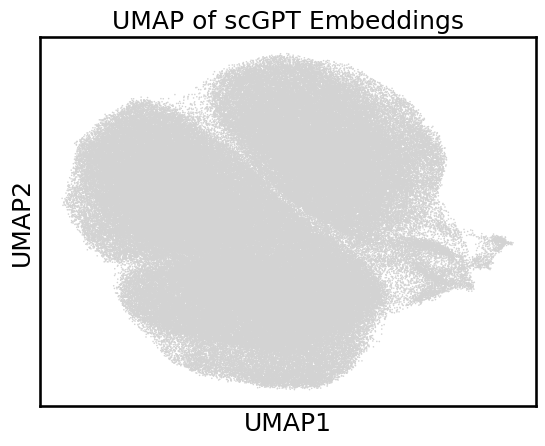

In [32]:
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import anndata

embedding_data = anndata.AnnData(X=adata.obsm['scgpt_embbeddings'])

# Run UMAP
sc.pp.neighbors(embedding_data, use_rep='X')
sc.tl.umap(embedding_data)

# Plot UMAP
sc.pl.umap(embedding_data, size=5, title="UMAP of scGPT Embeddings")

### srivatsan20

In [13]:
datapath = f'{data_cache_dir}/srivatsan20_processed.h5ad'

In [14]:
adata = sc.read_h5ad(datapath)

In [15]:
adata

AnnData object with n_obs × n_vars = 178213 × 8630
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'chembl-ID', 'dataset', 'cell_type', 'treatment', 'condition', 'dose', 'perturbation_raw', 'pert_cell_type', 'ood_split', 'cov_merged', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'control', 'dose_val', 'cov_drug_dose_name', '_scvi_cell_type'
    var: 'ensembl_id', 'ncounts', 'ncells', 'gene_symbol', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'm

In [16]:
adata_copy = adata.copy()

In [17]:
adata_copy.X = adata_copy.layers['counts']

In [ ]:
adata_copy_embeddings = scg.tasks.embed_data(
    adata_copy,
    model_dir,
    gene_col='index',
    batch_size=128,
    return_new_adata=True,
)

In [19]:
adata.obsm['scgpt_embbeddings'] = adata_copy_embeddings.X

In [20]:
adata

AnnData object with n_obs × n_vars = 178213 × 8630
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'chembl-ID', 'dataset', 'cell_type', 'treatment', 'condition', 'dose', 'perturbation_raw', 'pert_cell_type', 'ood_split', 'cov_merged', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'control', 'dose_val', 'cov_drug_dose_name', '_scvi_cell_type'
    var: 'ensembl_id', 'ncounts', 'ncells', 'gene_symbol', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'm

In [21]:
outfile = f'{data_cache_dir}/srivatsan20_highest_processed_with_embeddings.h5ad'

In [22]:
adata.write_h5ad(outfile)

In [15]:
import json
import os
from pathlib import Path
from typing import Optional, Union

import numpy as np
import scanpy as sc
import torch
from anndata import AnnData
from torch.utils.data import DataLoader, SequentialSampler
from tqdm import tqdm

from scgpt import logger
from scgpt.data_collator import DataCollator
from scgpt.model import TransformerModel
from scgpt.tokenizer import GeneVocab
from scgpt.utils import load_pretrained

gene_col = "index"
if gene_col == "index":
    adata.var["index"] = adata.var.index

PathLike = Union[str, os.PathLike]

# LOAD MODEL
model_dir = Path(model_dir)
vocab_file = model_dir / "vocab.json"
model_config_file = model_dir / "args.json"
model_file = model_dir / "best_model.pt"
pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]

# vocabulary
vocab = GeneVocab.from_file(vocab_file)
for s in special_tokens:
    if s not in vocab:
        vocab.append_token(s)
adata.var["id_in_vocab"] = [
    vocab[gene] if gene in vocab else -1 for gene in adata.var[gene_col]
]
gene_ids_in_vocab = np.array(adata.var["id_in_vocab"])
logger.info(
    f"match {np.sum(gene_ids_in_vocab >= 0)}/{len(gene_ids_in_vocab)} genes "
    f"in vocabulary of size {len(vocab)}."
)
adata = adata[:, adata.var["id_in_vocab"] >= 0]

with open(model_config_file, "r") as f:
    model_configs = json.load(f)

# Binning will be applied after tokenization. A possible way to do is to use the unified way of binning in the data collator.

vocab.set_default_index(vocab["<pad>"])
genes = adata.var[gene_col].tolist()
gene_ids = np.array(vocab(genes), dtype=int)

# all_counts = adata.layers["counts"]
# num_of_non_zero_genes = [
#     np.count_nonzero(all_counts[i]) for i in range(all_counts.shape[0])
# ]
# max_length = min(max_length, np.max(num_of_non_zero_genes) + 1)

model = TransformerModel(
    ntoken=len(vocab),
    d_model=model_configs["embsize"],
    nhead=model_configs["nheads"],
    d_hid=model_configs["d_hid"],
    nlayers=model_configs["nlayers"],
    nlayers_cls=model_configs["n_layers_cls"],
    n_cls=1,
    vocab=vocab,
    dropout=model_configs["dropout"],
    pad_token=model_configs["pad_token"],
    pad_value=model_configs["pad_value"],
    do_mvc=True,
    do_dab=False,
    use_batch_labels=False,
    domain_spec_batchnorm=False,
    explicit_zero_prob=False,
    use_fast_transformer=False,
    fast_transformer_backend="flash",
    pre_norm=False,
)
load_pretrained(model, torch.load(model_file, map_location="cuda"), verbose=False)
model.to("cuda")
model.eval()

/tmp/ipykernel_1355387/555499660.py:21: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["index"] = adata.var.index


scGPT - INFO - match 5235/5235 genes in vocabulary of size 60697.


TransformerModel(
  (encoder): GeneEncoder(
    (embedding): Embedding(60697, 512, padding_idx=60694)
    (enc_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): ContinuousValueEncoder(
    (dropout): Dropout(p=0.2, inplace=False)
    (linear1): Linear(in_features=1, out_features=512, bias=True)
    (activation): ReLU()
    (linear2): Linear(in_features=512, out_features=512, bias=True)
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, el

In [17]:
model

TransformerModel(
  (encoder): GeneEncoder(
    (embedding): Embedding(60697, 512, padding_idx=60694)
    (enc_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): ContinuousValueEncoder(
    (dropout): Dropout(p=0.2, inplace=False)
    (linear1): Linear(in_features=1, out_features=512, bias=True)
    (activation): ReLU()
    (linear2): Linear(in_features=512, out_features=512, bias=True)
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, el